For a real network

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, norm
import seaborn as sns

In [5]:
# Load rewiring file
rewiring_file = 'clustering_rewiring_cora.dat'
df_rewiring = pd.read_csv(rewiring_file, delim_whitespace=True, header=None, names=['degree', 'clustering'])
df_rewiring.dropna(inplace=True)  # Remove NaN values

df_rewiring['degree'] = pd.to_numeric(df_rewiring['degree'], errors='coerce')
df_rewiring['clustering'] = pd.to_numeric(df_rewiring['clustering'], errors='coerce')
df_rewiring.dropna(inplace=True)  # Remove NaN values after conversion

# Load sample file
sample_file = 'clustering_cora.dat'
df_sample = pd.read_csv(sample_file, delim_whitespace=True, header=None, names=['node', 'degree', 'clustering'])
df_sample.dropna(inplace=True)  # Remove NaN values

df_sample['degree'] = pd.to_numeric(df_sample['degree'], errors='coerce')
df_sample['clustering'] = pd.to_numeric(df_sample['clustering'], errors='coerce')
df_sample.dropna(inplace=True)  # Remove NaN values after conversion

# Get unique degrees from rewiring file
degrees_of_interest = df_rewiring['degree'].unique()

# Define percentiles
percentile_values = [50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 99, 99.9, 100]
percentiles = {p: {} for p in percentile_values}

# Compute percentiles for each degree
for degree in degrees_of_interest:
    clustering_values = df_rewiring[df_rewiring['degree'] == degree]['clustering']
    if len(clustering_values) > 0:
        for p in percentile_values:
            percentiles[p][degree] = np.percentile(clustering_values, p)
    else:
        for p in percentile_values:
            percentiles[p][degree] = None

# Function to calculate and display results for a given percentile
def calculate_and_display_results(df_sample, percentiles, threshold):
    total_within_threshold = 0
    total_nodes = 0
    df_sample[f'within_{threshold}'] = False

    for degree in degrees_of_interest:
        if degree in percentiles[threshold] and percentiles[threshold][degree] is not None:
            percentile_value = percentiles[threshold][degree]
            sample_degree = df_sample[df_sample['degree'] == degree]
            count_within_percentile = np.sum(sample_degree['clustering'] <= percentile_value)
            total_count = len(sample_degree)
            total_nodes += total_count
            total_within_threshold += count_within_percentile
            df_sample.loc[sample_degree.index, f'within_{threshold}'] = sample_degree['clustering'] <= percentile_value

    percentage_within_threshold = (total_within_threshold / total_nodes) * 100 if total_nodes > 0 else 0
    print(f"Threshold {threshold}th Percentile: {total_within_threshold} nodes ({percentage_within_threshold:.2f}%) within the threshold")

    output_file = f'clustering_sample1_within_{threshold}.dat'
    df_sample.to_csv(output_file, sep='\t', index=False, header=False)

# Process all percentiles
for p in percentile_values:
    calculate_and_display_results(df_sample, percentiles, p)

# Function to save nodes within percentile
def save_feat_inside_percentile(df_sample, threshold):
    column_name = f'within_{threshold}'
    if column_name not in df_sample.columns:
        print(f"Column '{column_name}' does not exist.")
        return
    
    feat_inside_percentile = df_sample[df_sample[column_name]]['node'].values
    df_inside_percentile = pd.DataFrame(feat_inside_percentile, columns=['node'])
    output_file = f'features_{threshold}.dat'
    df_inside_percentile.to_csv(output_file, sep='\t', index=False, header=False)
    #print(f"File '{output_file}' generated successfully.")

# Save all features inside percentiles
for p in percentile_values:
    save_feat_inside_percentile(df_sample, p)

# Load original data
sample0 = pd.read_csv('Cora_bipartite.txt', sep='\t', header=None, names=['node', 'feature'])

# Process all percentiles to filter and save data
for p in percentile_values:
    features_file = f'features_{p}.dat'
    features_inside = pd.read_csv(features_file, sep='\t', header=None, names=['feature'])
    filtered_sample0 = sample0[sample0['feature'].isin(features_inside['feature'])]
    output_file = f'cora_noise_{p}_it1.dat'
    filtered_sample0.to_csv(output_file, sep='\t', index=False, header=False)
    #print(f"File '{output_file}' generated successfully.")

# Process all percentiles for filtered data
for p in percentile_values:
    features_file = f'features_{p}.dat'
    features_inside = pd.read_csv(features_file, sep='\t', header=None, names=['feature'])
    filtered_sample0 = sample0[~sample0['feature'].isin(features_inside['feature'])]
    output_file = f'Cora_filtered_{p}.dat'
    filtered_sample0.to_csv(output_file, sep='\t', index=False, header=False)
    #print(f"File '{output_file}' generated successfully.")

Threshold 50th Percentile: 231 nodes (16.15%) within the threshold
Threshold 55th Percentile: 266 nodes (18.60%) within the threshold
Threshold 60th Percentile: 315 nodes (22.03%) within the threshold
Threshold 65th Percentile: 347 nodes (24.27%) within the threshold
Threshold 70th Percentile: 388 nodes (27.13%) within the threshold
Threshold 75th Percentile: 438 nodes (30.63%) within the threshold
Threshold 80th Percentile: 488 nodes (34.13%) within the threshold
Threshold 85th Percentile: 547 nodes (38.25%) within the threshold
Threshold 90th Percentile: 636 nodes (44.48%) within the threshold
Threshold 95th Percentile: 754 nodes (52.73%) within the threshold
Threshold 99th Percentile: 948 nodes (66.29%) within the threshold
Threshold 99.9th Percentile: 1117 nodes (78.11%) within the threshold
Threshold 100th Percentile: 1202 nodes (84.06%) within the threshold


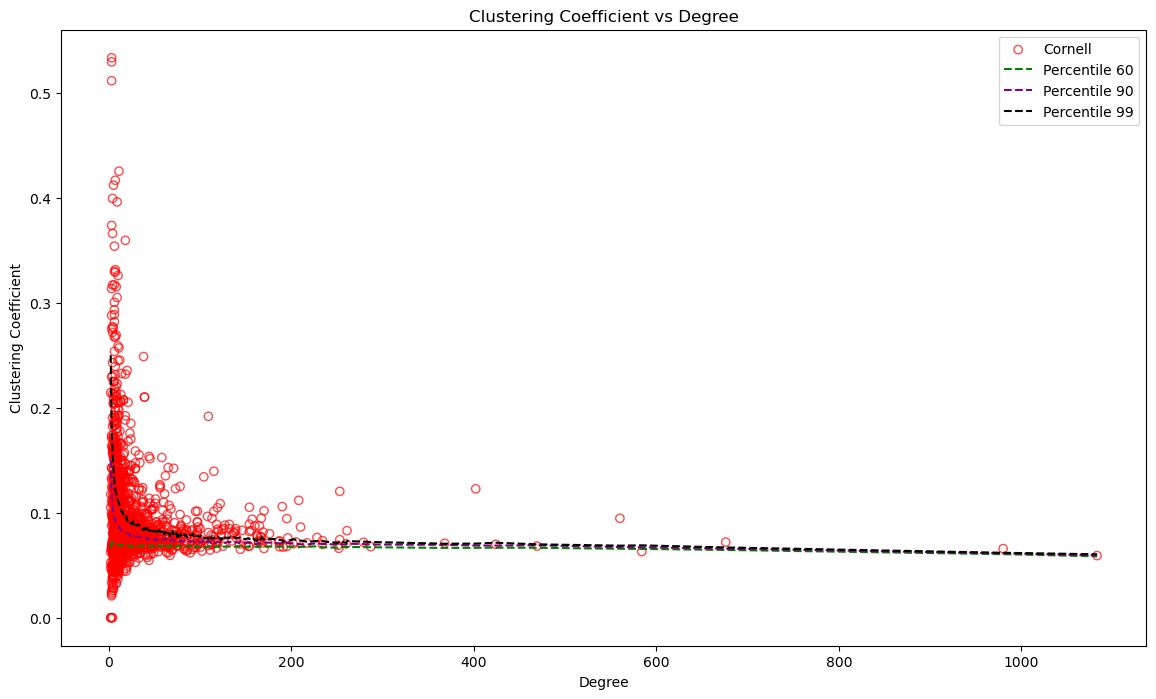

In [7]:
sample_file = 'clustering_cora.dat'
df_sample = pd.read_csv(sample_file, delim_whitespace=True, header=None, 
                        names=['node', 'degree', 'clustering'])

# Ensure the data is numeric
df_sample['degree'] = pd.to_numeric(df_sample['degree'], errors='coerce')
df_sample['clustering'] = pd.to_numeric(df_sample['clustering'], errors='coerce')

# Assuming df_rewiring is already loaded
# df_rewiring = pd.read_csv('rewiring_file.csv', delim_whitespace=True)

# Get all unique degrees from df_rewiring
degrees_of_interest = df_rewiring['degree'].unique()

# Calculate and store percentiles
percentiles_list = []
for degree in degrees_of_interest:
    clustering_values = df_rewiring[df_rewiring['degree'] == degree]['clustering']
    if len(clustering_values) > 0:
        percentile_60 = np.percentile(clustering_values, 60)
        percentile_90 = np.percentile(clustering_values, 90)
        percentile_99 = np.percentile(clustering_values, 99)
        percentiles_list.append({
            'degree': degree,
            'percentile_60': percentile_60,
            'percentile_90': percentile_90,
            'percentile_99': percentile_99
        })

# Create a DataFrame from percentiles list and save it to a file
percentiles_df = pd.DataFrame(percentiles_list)
percentiles_df.to_csv('percentiles_sample.dat', sep='\t', index=False, header=False)

# Load the percentiles data for plotting
df_percentiles = pd.read_csv('percentiles_sample.dat', delim_whitespace=True, header=None, 
                             names=['degree', 'percentile_60', 'percentile_90', 'percentile_99'])

# Ensure percentiles data is numeric
df_percentiles['degree'] = pd.to_numeric(df_percentiles['degree'], errors='coerce')
df_percentiles['percentile_60'] = pd.to_numeric(df_percentiles['percentile_60'], errors='coerce')
df_percentiles['percentile_90'] = pd.to_numeric(df_percentiles['percentile_90'], errors='coerce')
df_percentiles['percentile_99'] = pd.to_numeric(df_percentiles['percentile_99'], errors='coerce')

# Sort percentiles by degree for accurate line plotting
df_percentiles.sort_values('degree', inplace=True)

# Plotting
plt.figure(figsize=(14, 8))

# Scatter plot for df_sample
plt.scatter(df_sample['degree'], df_sample['clustering'], edgecolor='red', facecolor='none', label='Cornell', alpha=0.7)

# Plot percentile lines
plt.plot(df_percentiles['degree'], df_percentiles['percentile_60'], label='Percentile 60', color='green', linestyle='dashed')
plt.plot(df_percentiles['degree'], df_percentiles['percentile_90'], label='Percentile 90', color='purple', linestyle='dashed')
plt.plot(df_percentiles['degree'], df_percentiles['percentile_99'], label='Percentile 99', color='black', linestyle='dashed')

# Labels and title
plt.xlabel('Degree')
plt.ylabel('Clustering Coefficient')
plt.title('Clustering Coefficient vs Degree')
plt.legend()
plt.show()

# For synthetic networks


In [7]:
import pandas as pd
import numpy as np
import os

# Define sample range
num_samples = 1 # Cambia esto según la cantidad de muestras
percentile_values = [50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 99, 99.9, 100]

for X in range(0, num_samples + 1):
    print(f"Processing sample {X}...")
    
    # Load rewiring file
    rewiring_file = f'clustering_rewiring_samplep{X}.dat'
    df_rewiring = pd.read_csv(rewiring_file, delim_whitespace=True, header=None, names=['class', 'degree', 'clustering'])
    df_rewiring.dropna(inplace=True)
    df_rewiring['degree'] = pd.to_numeric(df_rewiring['degree'], errors='coerce')
    df_rewiring['clustering'] = pd.to_numeric(df_rewiring['clustering'], errors='coerce')
    df_rewiring.dropna(inplace=True)
    
    # Load sample file
    sample_file = f'clustering_samplep{X}.dat'
    df_sample = pd.read_csv(sample_file, delim_whitespace=True, header=None, names=['node', 'class', 'degree', 'clustering']) 
    df_sample.dropna(inplace=True)
    df_sample['degree'] = pd.to_numeric(df_sample['degree'], errors='coerce')
    df_sample['clustering'] = pd.to_numeric(df_sample['clustering'], errors='coerce')
    df_sample.dropna(inplace=True)
    
    # Get unique degrees from rewiring file
    degrees_of_interest = df_rewiring['degree'].unique()
    
    # Compute percentiles
    percentiles = {p: {} for p in percentile_values}
    for degree in degrees_of_interest:
        clustering_values = df_rewiring[df_rewiring['degree'] == degree]['clustering']
        if len(clustering_values) > 0:
            for p in percentile_values:
                percentiles[p][degree] = np.percentile(clustering_values, p)
        else:
            for p in percentile_values:
                percentiles[p][degree] = None
    
    # Total class counts
    total_class_1_original = df_sample[df_sample['class'] == 1].shape[0]
    total_class_2_original = df_sample[df_sample['class'] == 2].shape[0]
    
    results = []
    
    for p in percentile_values:
        total_class_1_within_threshold = 0
        total_class_2_within_threshold = 0
        
        df_sample[f'within_{p}'] = False
        
        for degree in degrees_of_interest:
            if degree in percentiles[p] and percentiles[p][degree] is not None:
                percentile_value = percentiles[p][degree]
                sample_degree = df_sample[df_sample['degree'] == degree]
                
                for class_label in [1, 2]:
                    class_values = sample_degree[sample_degree['class'] == class_label]
                    count_within_percentile = np.sum(class_values['clustering'] <= percentile_value)
                    
                    if class_label == 1:
                        total_class_1_within_threshold += count_within_percentile
                    else:
                        total_class_2_within_threshold += count_within_percentile
                    
                    df_sample.loc[class_values.index, f'within_{p}'] = class_values['clustering'] <= percentile_value
        
        signal_to_noise = (total_class_1_original - total_class_1_within_threshold) / (total_class_2_original - total_class_2_within_threshold) if (total_class_2_original - total_class_2_within_threshold) != 0 else float('inf')
        
        tp = total_class_2_within_threshold
        fp = total_class_1_within_threshold
        tn = total_class_1_original - total_class_1_within_threshold
        fn = total_class_2_original - total_class_2_within_threshold
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        results.append([p, total_class_1_within_threshold, total_class_2_within_threshold, signal_to_noise, tp, fp, tn, fn, precision, recall, f1_score])
        
    # Create output folder
    output_folder = f'sample_p{X}'
    os.makedirs(output_folder, exist_ok=True)
    
    # Save results with metrics
    df_results = pd.DataFrame(results, columns=['pvalue', 'removed_class1', 'removed_class2', 'signal_to_noise', 'true_positive', 'false_positive', 'true_negative', 'false_negative', 'precision', 'recall', 'f1_score'])
    output_file = os.path.join(output_folder, 'remotion_with_metrics.dat')
    df_results.to_csv(output_file, sep='\t', index=False, header=True)
    print(f"Results saved in {output_file}")

print("Processing complete.")


Processing sample 0...


FileNotFoundError: [Errno 2] No such file or directory: 'clustering_rewiring_samplep0.dat'

# Explore the networks

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [2]:
# -----------------------------
# Load and clean rewiring data
# -----------------------------
rewiring_file = 'clustering_rewiring_samplep0.dat'
df_rewiring = pd.read_csv(rewiring_file, delim_whitespace=True, header=None, names=['node', 'degree', 'clustering'])
df_rewiring.dropna(inplace=True)
df_rewiring['degree'] = pd.to_numeric(df_rewiring['degree'], errors='coerce')
df_rewiring['clustering'] = pd.to_numeric(df_rewiring['clustering'], errors='coerce')
df_rewiring.dropna(inplace=True)

# ------------------------------
# Compute histograms and PDFs
# ------------------------------
degrees_of_interest = [5, 20]
histograms, pdfs, percentiles = {}, {}, {}

for degree in degrees_of_interest:
    clustering_values = df_rewiring[df_rewiring['degree'] == degree]['clustering'].dropna()
    
    if len(clustering_values) > 1 and np.var(clustering_values) > 0:
        hist, bins = np.histogram(clustering_values, bins=20, density=True)
        histograms[degree] = (hist, bins)
        pdfs[degree] = gaussian_kde(clustering_values)
        percentiles[degree] = np.percentile(clustering_values, 95)

# ------------------------------
# Plot histograms and PDFs
# ------------------------------
for degree in degrees_of_interest:
    if degree in histograms:
        hist, bins = histograms[degree]
        kde = pdfs[degree]
        percentile_value = percentiles[degree]

        plt.figure()
        plt.hist(bins[:-1], bins, density=True, weights=hist, alpha=0.5, label='Histogram')
        x_range = np.linspace(bins[0], bins[-1], 100)
        plt.plot(x_range, kde(x_range), label='PDF')
        plt.axvline(percentile_value, color='r', linestyle='--', label=f'95th Percentile: {percentile_value:.3f}')
        plt.title(f'Degree: {degree}')
        plt.xlabel('Clustering')
        plt.ylabel('Density')
        plt.legend()
        plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'clustering_rewiring_samplep0.dat'

In [3]:
# -----------------------------
# Load and clean sample data
# -----------------------------
sample_file = 'clustering_samplep0.dat'
df_sample = pd.read_csv(sample_file, delim_whitespace=True, header=None, names=['node', 'class', 'degree', 'clustering'])
df_sample.dropna(inplace=True)
df_sample['degree'] = pd.to_numeric(df_sample['degree'], errors='coerce')
df_sample['clustering'] = pd.to_numeric(df_sample['clustering'], errors='coerce')
df_sample.dropna(inplace=True)

# -----------------------------
# Compare sample with rewiring
# -----------------------------
def plot_sample_comparison(degree, percentile_value):
    rewiring_data = df_rewiring[df_rewiring['degree'] == degree]
    sample_data = df_sample[df_sample['degree'] == degree]
    
    sample_class_1 = sample_data[sample_data['class'] == 1]['clustering']
    sample_class_2 = sample_data[sample_data['class'] == 2]['clustering']
    
    plt.figure(figsize=(10, 6))
    plt.hist(rewiring_data['clustering'], bins=20, density=True, alpha=0.6, color='gray', edgecolor='black')
    plt.scatter(sample_class_1, np.zeros_like(sample_class_1), color='red', label='signal', zorder=5)
    plt.scatter(sample_class_2, np.zeros_like(sample_class_2), color='blue', label='noise', zorder=5)
    plt.axvline(percentile_value, color='purple', linestyle='dashed', linewidth=2, label=f'95th Percentile')
    plt.legend()
    plt.title(f'Histogram for Degree {degree}')
    plt.xlabel('Clustering Coefficient')
    plt.ylabel('Density')
    plt.show()

for degree in degrees_of_interest:
    if degree in percentiles:
        plot_sample_comparison(degree, percentiles[degree])

FileNotFoundError: [Errno 2] No such file or directory: 'clustering_samplep0.dat'

In [4]:
# -----------------------------
# Compute additional percentiles
# -----------------------------
all_degrees = df_rewiring['degree'].unique()
percentiles_list = []

for degree in all_degrees:
    clustering_values = df_rewiring[df_rewiring['degree'] == degree]['clustering']
    if len(clustering_values) > 0:
        percentiles_list.append({
            'degree': degree,
            'percentile_60': np.percentile(clustering_values, 60),
            'percentile_90': np.percentile(clustering_values, 90),
            'percentile_99': np.percentile(clustering_values, 99)
        })

percentiles_df = pd.DataFrame(percentiles_list)
percentiles_df.to_csv('percentiles_sample.dat', sep='\t', index=False, header=False)

# -----------------------------
# Plot clustering vs degree
# -----------------------------
df_percentiles = pd.read_csv('percentiles_sample.dat', delim_whitespace=True, header=None, 
                             names=['degree', 'percentile_60', 'percentile_90', 'percentile_99'])
df_percentiles.sort_values('degree', inplace=True)

plt.figure(figsize=(8, 8))
plt.scatter(df_sample[df_sample['class'] == 1]['degree'], df_sample[df_sample['class'] == 1]['clustering'], edgecolor='red', facecolor='none', label='signal')
plt.scatter(df_sample[df_sample['class'] == 2]['degree'], df_sample[df_sample['class'] == 2]['clustering'], edgecolor='blue', facecolor='none', label='noise')
#plt.plot(df_percentiles['degree'], df_percentiles['percentile_60'], label='Percentile 60', color='green', linestyle='dashed')
plt.plot(df_percentiles['degree'], df_percentiles['percentile_95'], label='Percentile 90', color='purple', linestyle='dashed')
#plt.plot(df_percentiles['degree'], df_percentiles['percentile_99'], label='Percentile 99', color='black', linestyle='dashed')
plt.xlabel('Degree')
plt.ylabel('Clustering Coefficient')
plt.title('Clustering Coefficient vs Degree')
plt.legend()
plt.show()

NameError: name 'df_rewiring' is not defined